In [11]:
import rdflib
from rdflib import Graph, Namespace
from rdflib.namespace import RDF, RDFS, OWL, XSD
from rdflib import URIRef, Literal, BNode

# Visualization uses the Graphviz `dot` executable (see setup below).
import io
import shutil
import subprocess
from pathlib import Path
from IPython.display import SVG, display
from rdflib.tools.rdf2dot import rdf2dot


Creat an RDF graph about movies. The example in given in RDF Turtle serialization

In [12]:
g = Graph()
# create graph using turtle
turtledata = """\
PREFIX dbr: <http://dbpedia.org/resource/>
PREFIX dbo: <http://dbpedia.org/ontology/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ex: <http://example.org/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

dbr:John_Travolta 		rdf:type   				dbo:Actor ;
                        dbo:awards 				dbr:67th_Academy_Awards ;
                        ex:portrays				dbr:Vincent_Vega .
dbr:Pulp_Fiction  		rdf:type  				dbo:Film ;
                        rdfs:label				"Pulp_Fiction"@en ,
                        "Кримінальне чтиво"@ua ;
                        dbo:genre     			dbr:Neo_noir ;
                        ex:playsIn 				dbr:Los_Angeles ;
                        ex:fictionalCharacter 	dbr:Vincent_Vega ;
                        dbo:starring  			dbr:John_Travolta ,
                        dbr:Uma_Thurman ,
                        dbr:Bruce_Willis .
dbr:Vincent_Vega 	  	rdf:type 				dbo:Fictional_character .
dbr:Quentin_Tarantino   rdf:type 				dbo:Director .
dbr:Uma_Thurman			rdf:type 				dbo:Actor ;
						ex:portrays				dbr:Mia_Wallace ;
						dbo:awards  			dbr:67th_Academy_Awards .
dbr:Bruce_Willis		rdf:type   				dbo:Actor .
dbr:The_Green_Mile		rdf:type  				dbo:Film ;
						rdfs:label				"The Green Mile"@en ,
                        "Зелена миля"@ua ;
                        dbo:starring			dbr:Tom_Hanks,
                        dbr:David_Morse .
dbr:Tom_Hanks			rdf:type 				dbo:Actor .
dbr:David_Morse			rdf:type 				dbo:Actor .
dbr:Tenet				rdf:type  				dbo:Film ;
                        rdfs:label				"Tenet"@en ;
                        dbo:starring 			dbr:Robert_Pattinson ,
                        dbr:Elizabeth_Debicki ,
                        dbr:John_David_Washington .
dbr:Robert_Pattinson 	rdf:type 				dbo:Actor .
dbr:Elizabeth_Debicki   rdf:type 				dbo:Actor .
dbr:John_David_Washington rdf:type 				dbo:Actor ."""

g.parse(data=turtledata, format="turtle")

<Graph identifier=N202a2bada86c4996bc42087a9f3cd826 (<class 'rdflib.graph.Graph'>)>

In [13]:
#print all triples
for s, p, o in g:
   print((s, p, o))

(rdflib.term.URIRef('http://dbpedia.org/resource/Uma_Thurman'), rdflib.term.URIRef('http://example.org/portrays'), rdflib.term.URIRef('http://dbpedia.org/resource/Mia_Wallace'))
(rdflib.term.URIRef('http://dbpedia.org/resource/Tom_Hanks'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://dbpedia.org/ontology/Actor'))
(rdflib.term.URIRef('http://dbpedia.org/resource/Pulp_Fiction'), rdflib.term.URIRef('http://dbpedia.org/ontology/starring'), rdflib.term.URIRef('http://dbpedia.org/resource/Bruce_Willis'))
(rdflib.term.URIRef('http://dbpedia.org/resource/The_Green_Mile'), rdflib.term.URIRef('http://dbpedia.org/ontology/starring'), rdflib.term.URIRef('http://dbpedia.org/resource/David_Morse'))
(rdflib.term.URIRef('http://dbpedia.org/resource/Pulp_Fiction'), rdflib.term.URIRef('http://www.w3.org/2000/01/rdf-schema#label'), rdflib.term.Literal('Pulp_Fiction', lang='en'))
(rdflib.term.URIRef('http://dbpedia.org/resource/Elizabeth_Debicki'), rdfl

In [14]:
#Save the graph
g.serialize(destination="filmgraph.ttl")

<Graph identifier=N202a2bada86c4996bc42087a9f3cd826 (<class 'rdflib.graph.Graph'>)>

### RDF Graph Serialization
We can select different serialization formats.

In [15]:
print(g.serialize(format="xml"))    #print RDF/XML

<?xml version="1.0" encoding="utf-8"?>
<rdf:RDF
   xmlns:dbo="http://dbpedia.org/ontology/"
   xmlns:ex="http://example.org/"
   xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
   xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#"
>
  <rdf:Description rdf:about="http://dbpedia.org/resource/Uma_Thurman">
    <rdf:type rdf:resource="http://dbpedia.org/ontology/Actor"/>
    <ex:portrays rdf:resource="http://dbpedia.org/resource/Mia_Wallace"/>
    <dbo:awards rdf:resource="http://dbpedia.org/resource/67th_Academy_Awards"/>
  </rdf:Description>
  <rdf:Description rdf:about="http://dbpedia.org/resource/Tom_Hanks">
    <rdf:type rdf:resource="http://dbpedia.org/ontology/Actor"/>
  </rdf:Description>
  <rdf:Description rdf:about="http://dbpedia.org/resource/Pulp_Fiction">
    <rdf:type rdf:resource="http://dbpedia.org/ontology/Film"/>
    <rdfs:label xml:lang="en">Pulp_Fiction</rdfs:label>
    <rdfs:label xml:lang="ua">Кримінальне чтиво</rdfs:label>
    <dbo:genre rdf:resource="http://

### Visualizing the Graph

Run the cells above first to populate `g`, then run the next cell.
Install **Graphviz** once if `dot` is not on your PATH:

- Ubuntu/Debian: `sudo apt install graphviz`
- macOS: `brew install graphviz`
- Windows: `winget install Graphviz.Graphviz` (restart VS Code afterward)

The diagram uses arrows for predicates, resource nodes for entities/classes,
and tables inside nodes for literal values such as movie labels.
The SVG stays sharp when zoomed and is also saved as `filmgraph.svg`.


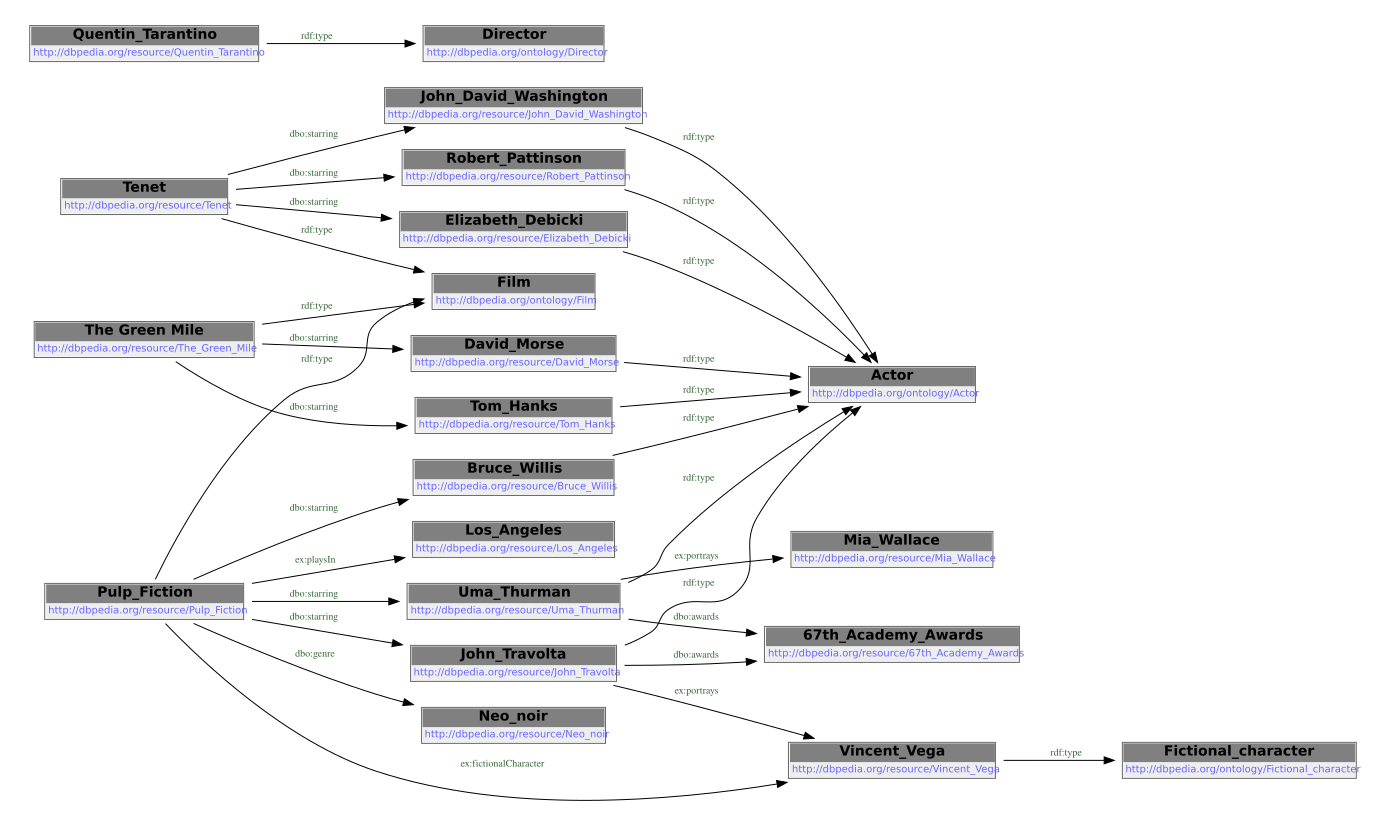

33 triples · Saved to filmgraph.svg


In [16]:
def visualize(graph, output="filmgraph.svg"):
    """Display an RDF graph as SVG and save a copy for viewing or sharing."""
    dot = shutil.which("dot")
    if dot is None:
        raise RuntimeError(
            "Graphviz is required. Install it using the instructions above, "
            "restart VS Code, then rerun this cell."
        )
    if not graph:
        print("The graph is empty. Run the Turtle parsing cell first.")
        return

    stream = io.StringIO()
    rdf2dot(graph, stream)
    result = subprocess.run(
        [dot, "-Tsvg", "-Grankdir=LR", "-Gbgcolor=white", "-Gpad=0.3"],
        input=stream.getvalue(), text=True, capture_output=True, check=True,
    )
    if output is not None:
        Path(output).write_text(result.stdout, encoding="utf-8")
    display(SVG(data=result.stdout))
    print(f"{len(graph)} triples" + (f" · Saved to {output}" if output else ""))


visualize(g)
